In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [180]:
df = pd.read_csv('WeatherAUS.csv')
#https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

In [181]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [182]:
df["Cloud9am"].unique()

array([ 8., nan,  7.,  1.,  0.,  5.,  4.,  2.,  6.,  3.,  9.])

In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [184]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [185]:
df.shape

(145460, 23)

In [186]:
for i in df.columns:

    threshold = 0.33

    NaNPercentage = df[i].isnull().sum()/len(df)

    if NaNPercentage > threshold:
        df.drop(i, axis=1, inplace=True)

In [187]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [188]:
temp = ["Temp9am","Temp3pm","MinTemp","MaxTemp","WindSpeed9am","WindSpeed3pm","WindGustSpeed","Humidity9am","Humidity3pm"]

In [189]:
df[temp] = df[temp].fillna(df[temp].median())

In [190]:
df = df.fillna(df.mode().iloc[0])

In [191]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [192]:
for x in df.columns:
    print("--------------")
    print("**")
    print("Column Name : ",x)
    print("**")

    print(df[x].unique())

--------------
**
Column Name :  Date
**
<ArrowStringArray>
['2008-12-01', '2008-12-02', '2008-12-03', '2008-12-04', '2008-12-05',
 '2008-12-06', '2008-12-07', '2008-12-08', '2008-12-09', '2008-12-10',
 ...
 '2008-01-22', '2008-01-23', '2008-01-24', '2008-01-25', '2008-01-26',
 '2008-01-27', '2008-01-28', '2008-01-29', '2008-01-30', '2008-01-31']
Length: 3436, dtype: str
--------------
**
Column Name :  Location
**
<ArrowStringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dar

In [193]:
df_cat = df.select_dtypes(include=['str'])

In [194]:
df_cat.head()

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,W,W,WNW,No,No
1,2008-12-02,Albury,WNW,NNW,WSW,No,No
2,2008-12-03,Albury,WSW,W,WSW,No,No
3,2008-12-04,Albury,NE,SE,E,No,No
4,2008-12-05,Albury,W,ENE,NW,No,No


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48],
 [Text(0, 0, 'Albury'),
  Text(1, 0, 'BadgerysCreek'),
  Text(2, 0, 'Cobar'),
  Text(3, 0, 'CoffsHarbour'),
  Text(4, 0, 'Moree'),
  Text(5, 0, 'Newcastle'),
  Text(6, 0, 'NorahHead'),
  Text(7, 0, 'NorfolkIsland'),
  Text(8, 0, 'Penrith'),
  Text(9, 0, 'Richmond'),
  Text(10, 0, 'Sydney'),
  Text(11, 0, 'SydneyAirport'),
  Text(12, 0, 'WaggaWagga'),
  Text(13, 0, 'Williamtown'),
  Text(14, 0, 'Wollongong'),
  Text(15, 0, 'Canberra'),
  Text(16, 0, 'Tuggeranong'),
  Text(17, 0, 'MountGinini'),
  Text(18, 0, 'Ballarat'),
  Text(19, 0, 'Bendigo'),
  Text(20, 0, 'Sale'),
  Text(21, 0, 'MelbourneAirport'),
  Text(22, 0, 'Melbourne'),
  Text(23, 0, 'Mildura'),
  Text(24, 0, 'Nhil'),
  Text(25, 0, 'Portland'),
 

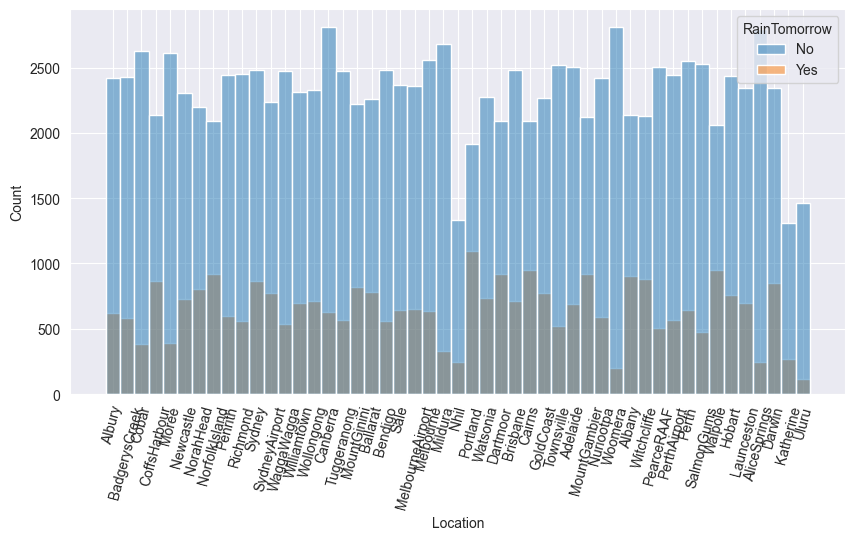

In [195]:
plt.figure(figsize=(10,5))
sns.histplot(x='Location', hue='RainTomorrow', data=df)
plt.xticks(rotation=75)

In [196]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = ["Location","WindGustDir","WindDir9am","WindDir3pm","RainToday","RainTomorrow"]

for col in cols:
    df[col] = le.fit_transform(df[col])

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  int64  
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   WindGustDir    145460 non-null  int64  
 6   WindGustSpeed  145460 non-null  float64
 7   WindDir9am     145460 non-null  int64  
 8   WindDir3pm     145460 non-null  int64  
 9   WindSpeed9am   145460 non-null  float64
 10  WindSpeed3pm   145460 non-null  float64
 11  Humidity9am    145460 non-null  float64
 12  Humidity3pm    145460 non-null  float64
 13  Pressure9am    145460 non-null  float64
 14  Pressure3pm    145460 non-null  float64
 15  Temp9am        145460 non-null  float64
 16  Temp3pm        145460 non-null  float64
 17  RainToday      145460 non-null  int64  


In [198]:
df['Date'] = pd.to_datetime(df['Date'])

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[us]
 1   Location       145460 non-null  int64         
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   WindGustDir    145460 non-null  int64         
 6   WindGustSpeed  145460 non-null  float64       
 7   WindDir9am     145460 non-null  int64         
 8   WindDir3pm     145460 non-null  int64         
 9   WindSpeed9am   145460 non-null  float64       
 10  WindSpeed3pm   145460 non-null  float64       
 11  Humidity9am    145460 non-null  float64       
 12  Humidity3pm    145460 non-null  float64       
 13  Pressure9am    145460 non-null  float64       
 14  Pressure3pm    145460 non-null  float64       
 15  Temp9am    

In [200]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [201]:
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day
df = df.drop('Date', axis=1)

In [202]:
df.shape

(145460, 21)

In [203]:
percentage = df['RainTomorrow'].value_counts(normalize=True)

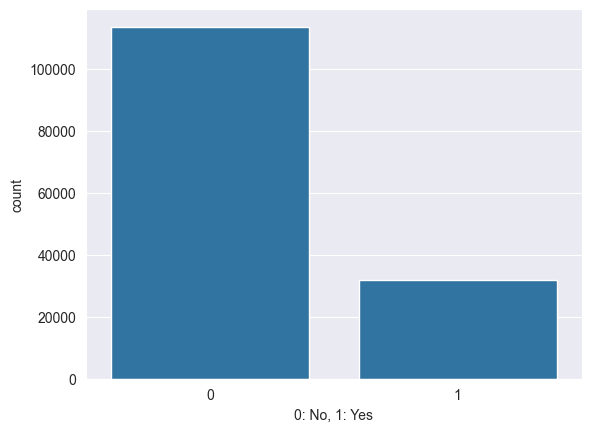

In [204]:
sns.countplot(x='RainTomorrow', data=df)

plt.xlabel('0: No, 1: Yes')
plt.show()

<Axes: >

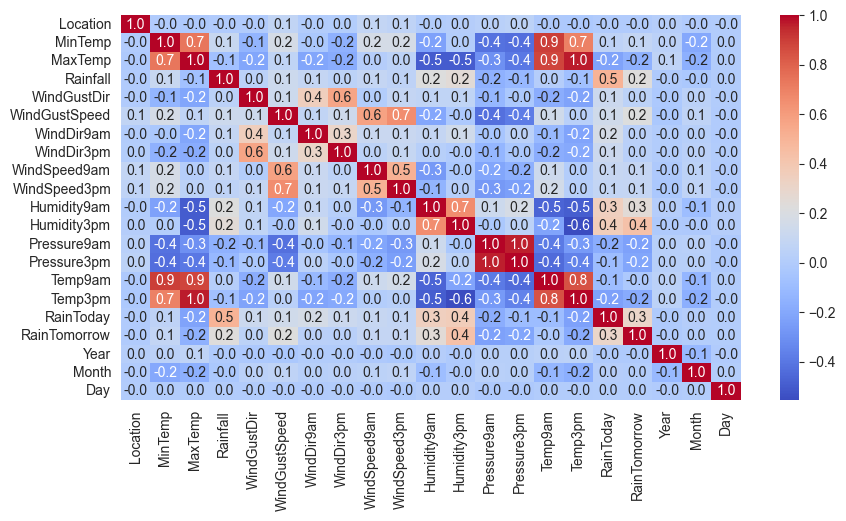

In [205]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm')

<Axes: xlabel='RainTomorrow', ylabel='Humidity3pm'>

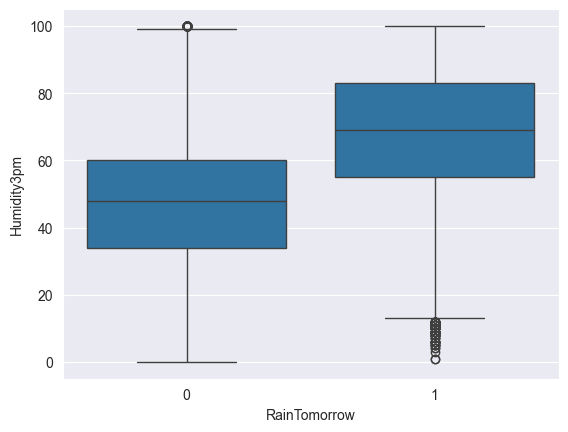

In [206]:
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)

<Axes: xlabel='Pressure9am', ylabel='Count'>

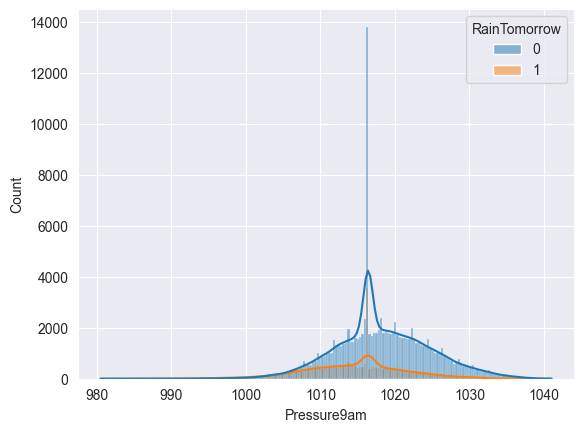

In [207]:
sns.histplot(data=df, x='Pressure9am', hue='RainTomorrow', kde=True)

<Axes: xlabel='RainToday', ylabel='count'>

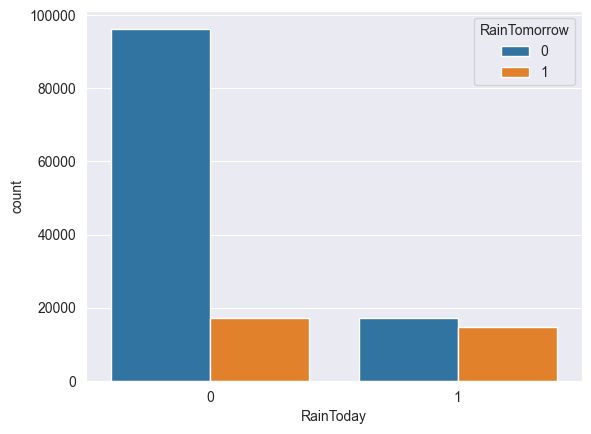

In [208]:
sns.countplot(x='RainToday', hue='RainTomorrow', data=df)

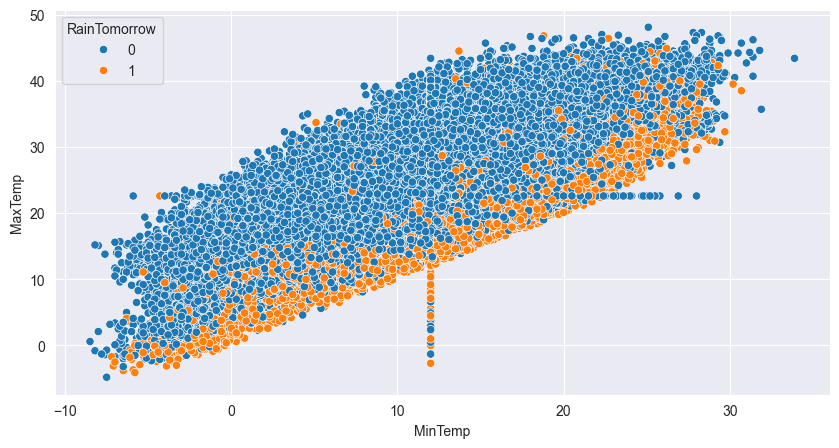

In [209]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='MinTemp', y='MaxTemp', hue='RainTomorrow', data=df, alpha=1)
plt.show()

<Axes: xlabel='Pressure9am', ylabel='Pressure3pm'>

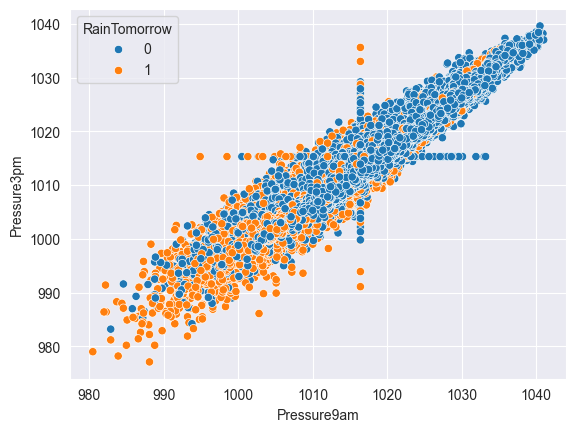

In [210]:
sns.scatterplot(x='Pressure9am', y='Pressure3pm', hue='RainTomorrow', alpha=1,data=df)

In [211]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

In [212]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [213]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8053416746871992
              precision    recall  f1-score   support

           0       0.86      0.89      0.88     22672
           1       0.57      0.51      0.53      6420

    accuracy                           0.81     29092
   macro avg       0.72      0.70      0.71     29092
weighted avg       0.80      0.81      0.80     29092



In [214]:
from sklearn.model_selection import GridSearchCV

In [215]:
param = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

In [216]:
grid = GridSearchCV(estimator=GaussianNB(),param_grid=param,n_jobs=-1)

In [217]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [218]:
grid.predict(X_test)

array([1, 0, 0, ..., 0, 0, 0], shape=(29092,))

In [219]:
grid.best_score_

np.float64(0.8089852939487205)

In [220]:
grid.best_params_

{'var_smoothing': 1e-05}

In [221]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [222]:
print("Test Accuracy:", accuracy_score(y_test, grid.predict(X_test)))
print(classification_report(y_test, grid.predict(X_test)))

Test Accuracy: 0.8063041385948027
              precision    recall  f1-score   support

           0       0.86      0.89      0.88     22672
           1       0.57      0.50      0.53      6420

    accuracy                           0.81     29092
   macro avg       0.72      0.70      0.71     29092
weighted avg       0.80      0.81      0.80     29092

